In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image, ImageDraw
from huggingface_hub import hf_hub_download
from ultralytics import YOLO
from supervision import Detections
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import scipy
from datasets.nsd import fetch_dataloaders

In [2]:
class model_argObj:
    def __init__(self):

        self.data_dir = '/engram/nklab/algonauts/algonauts_2023_challenge_data/'
        self.backbone_arch = 'dinov2_q'
        self.train  = 'test'
        self.batch_size = 32
        self.image_size = None
        self.saved_feats = None
        self.saved_feats_dir = ''


def denormalize(tensor):
    """Denormalizes a tensor image."""
    mean = [0.485, 0.456, 0.406]  # Mean used for normalization
    std = [0.229, 0.224, 0.225]  # Standard deviation used for normalization
    # Create an inverse transform
    inv_normalize = transforms.Normalize(
        mean=[-m / s for m, s in zip(mean, std)],
        std=[1 / s for s in std])
    # Convert the tensor to a PIL Image
    to_pil = transforms.ToPILImage()
    image = to_pil(inv_normalize(tensor))
    return image


lh_roi_names = ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'EBA', 'FBA-1', 'FBA-2', 
                'mTL-bodies', 'OFA', 'FFA-1', 'FFA-2', 'mTL-faces', 'aTL-faces', 
                'OPA', 'PPA', 'RSC', 'OWFA', 'VWFA-1', 'VWFA-2', 'mfs-words', 'mTL-words']
rh_roi_names = lh_roi_names


In [3]:
model_face = YOLO(hf_hub_download(repo_id="arnabdhar/YOLOv8-Face-Detection", filename="model.pt"))
model_obj = torch.hub.load("ultralytics/yolov5", "yolov5s")

Using cache found in /home/ms5724/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-7-28 Python-3.11.5 torch-2.0.1 CUDA:0 (NVIDIA A40, 45403MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients
Adding AutoShape... 


In [4]:
del model_face, model_obj

In [ ]:
for subj in range(1, 9):

    args = model_argObj()
    args.subj = format(subj, '02')
    args.data_dir = os.path.join(args.data_dir, 'subj'+args.subj)
    test_loader = fetch_dataloaders(args, train='test')
    
    images_all = []
    for i_batch, images in enumerate(test_loader):
        for image in images:
            images_all.append(np.array(denormalize(image))[None, ...])
    images_all = np.concatenate(images_all, axis=0)
    print(images_all.shape)
    np.save(f'./results/images_all_subj{subj}.npy', images_all)


Test stimulus images: 159
(159, 434, 434, 3)

Test stimulus images: 159


In [4]:
# Create mask utility
def fill_box(label_map, box, class_value, only_where=None):
    x1, y1, x2, y2 = map(int, box)
    region = label_map[y1:y2, x1:x2]
    if only_where is None:
        region[...] = class_value
    else:
        region[only_where(region)] = class_value
    label_map[y1:y2, x1:x2] = region

In [5]:
# Define categories
animal_classes = ['cat', 'dog', 'bird', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe']
food_classes = ['banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'pizza', 'donut', 'cake', 'hot dog']
face_class = 'face'
person_class = 'person'
vehicle_class = ['bus', 'truck', 'train', 'airplane', 'bicycle', 'boat', 'car', 'motorcycle']
furniture_class = ['chair', 'couch', 'bed', 'bench', 'dining table']
kichen_class = ['fork', 'knife', 'spoon', 'cup', 'bowl', 'toaster', 'oven', 'microwave', 'refrigerator', 'sink', 'wine glass', 'bottle']
electronics_class = ['tv', 'remote', 'keyboard', 'laptop', 'cell phone', 'mouse', 'clock', 'hair drier']
sports_class = ['baseball glove', 'baseball bat', 'tennis racket', 'sports ball', 'frisbee', 'skateboard', 'skis']
accessories_class = ['backpack', 'handbag', 'tie', 'suitcase', 'umbrella']
street_class = ['stop sign', 'traffic light', 'parking meter', 'fire hydrant']

In [7]:
for subj in [1]: #range(1, 9):
    images_all = np.load(f'./results/images_all_subj{subj}.npy')
    
    label_map_list = []
    
    for i in range(len(images_all)):
    
        image = Image.fromarray(images_all[i])
        ##############################
        results_face = Detections.from_ultralytics(model_face(image)[0])
        results_obj = model_obj(image)
        #############################
        # Step 0: Prepare
        W, H = image.size
        label_map = np.zeros((H, W), dtype=np.uint8)
        ###########################
        # Step 1: Fill COCO detections
        names = results_obj.names
        for i in range(len(results_obj.xyxy[0])):
            box = results_obj.xyxy[0][i]
            x1, y1, x2, y2, conf, cls = box.tolist()
            label = names[int(cls)]
            if label == person_class:
                fill_box(label_map, (x1, y1, x2, y2), 2)
            elif label in animal_classes:
                fill_box(label_map, (x1, y1, x2, y2), 3)
            elif label in food_classes:
                fill_box(label_map, (x1, y1, x2, y2), 4)
            # elif label in vehicle_class:
            #     fill_box(label_map, (x1, y1, x2, y2), 5)
            # elif label in furniture_class:
            #     fill_box(label_map, (x1, y1, x2, y2), 6)
            # elif label in kichen_class:
            #     fill_box(label_map, (x1, y1, x2, y2), 7)
            # elif label in electronics_class:
            #     fill_box(label_map, (x1, y1, x2, y2), 8)
            # elif label in sports_class:
            #     fill_box(label_map, (x1, y1, x2, y2), 9)
            # elif label in accessories_class:
            #     fill_box(label_map, (x1, y1, x2, y2), 10)
            # elif label in street_class:
            #     fill_box(label_map, (x1, y1, x2, y2), 11)
            else:
                pass
        ###########################
        # Step 2: Fill face regions
        results = results_face
        for i in range(len(results.xyxy)):
            box = results.xyxy[i]  
            fill_box(label_map, box[:4], 1, only_where=lambda r: r == 2)
        #############################
        # draw = ImageDraw.Draw(image)
        # results = results_face
        # for i in range(len(results.xyxy)):
        #     box = results.xyxy[i]  
        #     label = results.data['class_name'][i]
        #     conf = results.confidence[i]
        #     draw.rectangle(box.tolist(), outline="red", width=3)
        #     draw.text((box[0], box[1] - 10), f"{label} {conf:.2f}", fill="red")
        # results = results_obj
        # for i in range(len(results.xyxy[0])):  # xyxy is a list of tensors, one per image
        #     box = results.xyxy[0][i]           # tensor: (x1, y1, x2, y2, conf, cls)
        #     x1, y1, x2, y2, conf, cls = box.tolist()
        #     label = results.names[int(cls)]
        #     draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
        #     draw.text((x1, y1 - 10), f"{label} {conf:.2f}", fill="red")
        
        # fig, axes = plt.subplots(1, 2, figsize=(6, 3))
        # ax = axes[0]
        # ax.imshow(image)
        # ax = axes[1]
        # im = ax.imshow(label_map)
        # ax.axis('off')
        # fig.colorbar(im, ax=ax)
        #############################
        label_map_list.append(label_map)
    
    label_map_list = np.array(label_map_list)
    print(label_map_list.shape)
    np.save(f'./results/label_map_all_subj{subj}.npy', label_map_list)


0: 640x640 (no detections), 22.4ms
Speed: 2.9ms preprocess, 22.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 9.1ms
Speed: 1.6ms preprocess, 9.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 5.1ms
Speed: 1.6ms preprocess, 5.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 5.0ms
Speed: 1.6ms preprocess, 5.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 5.0ms
Speed: 1.6ms preprocess, 5.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 5.0ms
Speed: 1.6ms preprocess, 5.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 FACE, 5.0ms
Speed: 1.6ms preprocess, 5.0ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 FACEs, 5.0ms
Speed: 1.6ms preprocess, 5.0ms inference, 1.0ms postprocess per

In [4]:
%matplotlib inline

In [5]:
del label_map_all, images_all, attn_all, attn_all_small

In [6]:
# label map: 0-background, 1-face, 2-body, 3-animal, 4-food
subj = 7
label_map_sfx = ['', '_extended'][0]
att_type = ['rois_all', 'rois_all_ul'][0]
roi_area_list = np.load(f'/engram/nklab/ms5724/transformer_brain_encoder/results/roi_area_list_subj{subj}.npy')
label_map_all = np.load(f'/engram/nklab/ms5724/transformer_brain_encoder/results/label_map{label_map_sfx}_all_subj{subj}.npy')
images_all = np.load(f'/engram/nklab/ms5724/transformer_brain_encoder/results/images_all_subj{subj}.npy')
attn_all_small = np.load(f'/engram/nklab/hossein/recurrent_models/transformer_brain_encoder'
                         f'/results/nsd_test/dinov2_q_transformer/subj_0{subj}/{att_type}/dec_atts.npy')
attn_all = scipy.ndimage.zoom(attn_all_small, [1, 1, 14, 14], order=0, mode='wrap')
print(label_map_all.shape, images_all.shape, attn_all.shape, )

(159, 434, 434) (159, 434, 434, 3) (159, 50, 434, 434)


In [7]:
num_classes = 5 if label_map_sfx == '' else 12
if att_type == 'rois_all':
    roi_names_all = lh_roi_names + ['none'] + rh_roi_names + ['none']
else:
    roi_names_all = lh_roi_names + [f'lh_ul{i}' for i in range(1, 11)] + ['none']
    roi_names_all += rh_roi_names + [f'rh_ul{i}' for i in range(1, 11)] + ['none']

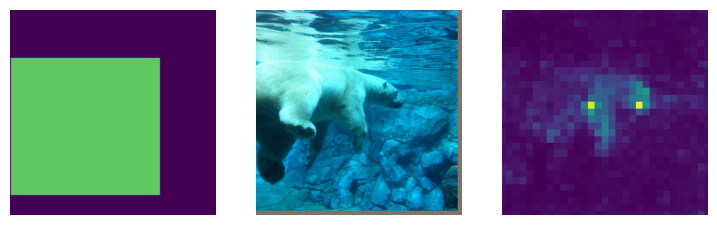

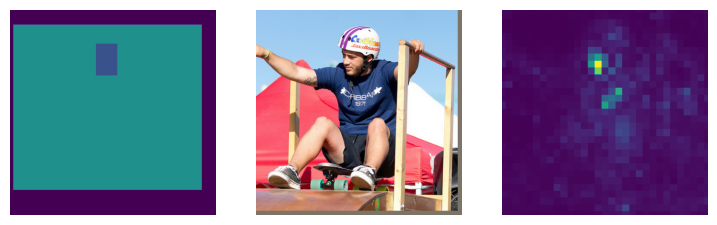

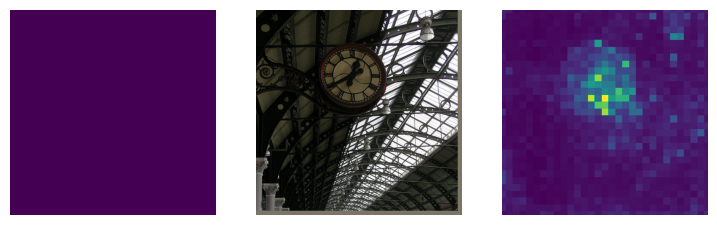

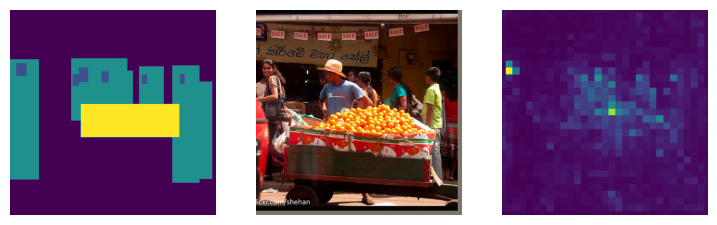

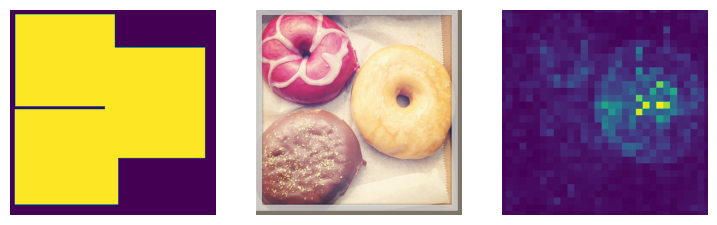

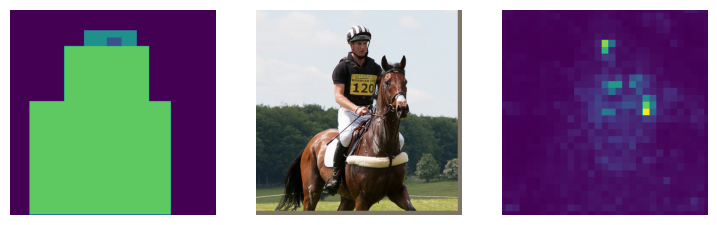

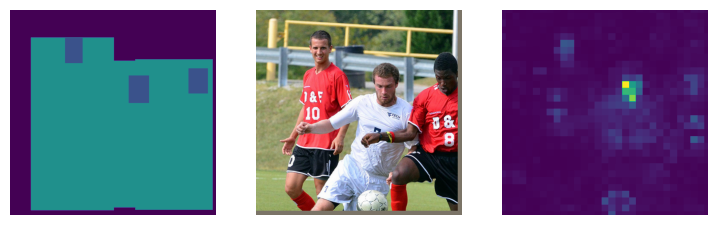

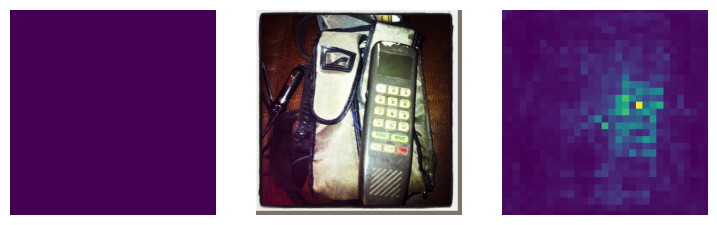

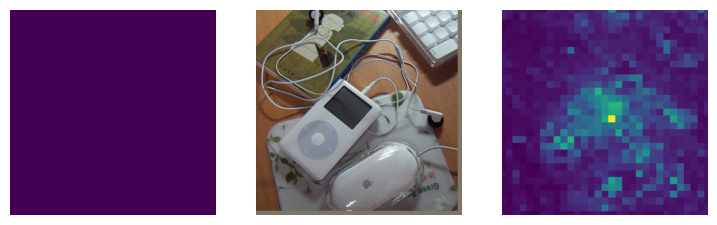

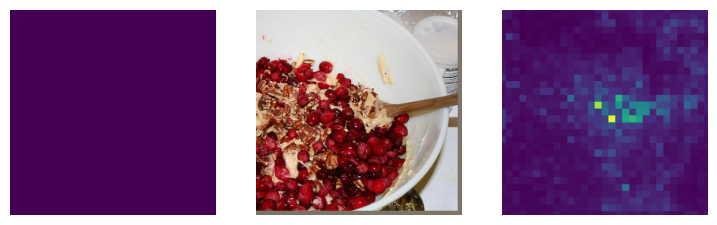

In [8]:
for idx in np.random.randint(len(images_all), size=10):
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(label_map_all[idx], vmin=0, vmax=num_classes-1)
    axes[1].imshow(images_all[idx])
    axes[2].imshow(attn_all[idx, 12])
    for ax in axes:
        ax.axis('off')

In [9]:
np.set_printoptions(precision=2, floatmode='fixed')
roi_names = ['EBA', 'FFA-1', 'FFA-2', 'OPA', 'PPA', 'RSC']
counts_collect = []
for roi_name in roi_names:
    if roi_name not in roi_names_all:
        continue
    i_rois = [i for i in range(len(roi_names_all)) if roi_names_all[i] == roi_name]
    selected_labels = []
    for i_roi in i_rois:
        if att_type == 'rois_all' and roi_area_list[i_roi] == 0:
            continue
        attn_map = attn_all[:, i_roi, :, :]
        threshold = np.sort(np.unique(attn_map.flatten()))[-10]
        selected_labels += list(label_map_all[attn_map >= threshold])
    selected_labels = np.array(selected_labels)
    counts_labels = [np.sum(selected_labels == i) for i in range(num_classes)] 
    counts_labels = counts_labels / np.sum(counts_labels) if np.sum(counts_labels) > 0 else counts_labels
    counts_labels = np.round(counts_labels, 2)
    counts_collect.append(counts_labels)
    print(roi_name, counts_labels)
# print(counts_collect)
print(np.sum(attn_map >= threshold))

EBA [0.38 0.05 0.43 0.09 0.05]
FFA-1 [0.00 0.88 0.02 0.10 0.00]
FFA-2 [0.17 0.20 0.38 0.20 0.05]
OPA [0.40 0.18 0.14 0.28 0.00]
PPA [0.51 0.29 0.16 0.05 0.00]
RSC [0.56 0.25 0.17 0.02 0.00]
1900


In [ ]:
['background', 'face', 'person', 'animal', 'food', 'vehicle', 'furniture', 'kitchen', 'electronics', 'sports', 'accessories_class',  'street_class']

|       | background | face | body | animal | food |
|-------|------------|------|------|--------|------|
| EBA | 0.03        | 0.36  | 0.61 | 0.00   | 0.00 |
| FFA-1  |  0.00    | 0.79  | 0.16 | 0.05   | 0.00 |
| FFA-2 | 0.00      | 0.83  | 0.17 | 0.00   | 0.00 |
| OPA | 0.54        | 0.12  | 0.14 | 0.05   | 0.15 |
| PPA | 0.44        | 0.25  | 0.11 |  0.10  | 0.10 |
| RSC | 0.66        | 0.23  | 0.11 | 0.00   | 0.00 |